In [1]:
import os
import caesar
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import modules as anal
import modules.anal_func as anal_func

from astropy.cosmology import LambdaCDM
import astropy.units as u
from astropy.io import fits
from scipy import interpolate

from modules.anal_func.build_history import BuildHistory
from modules.anal_func.read_progenitors import read_progen

from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


cosmo = LambdaCDM(H0 = 68, Om0= 0.3, Ode0= 0.7, Ob0=0.048)
plt.rcParams.update({'font.size': 28})

In [2]:
# initialize the Simba class, which import the needed paths
sb = anal.Simba('PC39BP4', size=100)
# initialize the SavePaths class to create destinations
sv = anal.SavePaths() 
pltsv  = sv.get_filetype_path('plot')
scatter = sv.create_subdir(pltsv, 'scatter')

In [5]:
cs = sb.get_caesar(148)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sfh = BuildHistory(sb, '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', progfilename='progenitors_recursive.fits') #'progenitors_recursive.fits') #'progenitors_most_mass_nocaesar.fits')

yt : [INFO     ] 2025-06-19 14:14:51,669 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_148.hdf5
yt : [INFO     ] 2025-06-19 14:14:51,914 Found 467847 halos
yt : [INFO     ] 2025-06-19 14:14:52,744 Found 54406 galaxies


In [58]:
hist = sfh.get_history_indx(totids[:], start_snap=150, end_snap=61)

In [59]:
positions = sfh.get_property_history(['pos_0', 'pos_1' , 'pos_2', 'GroupID', 'sfr', 'stellar_masses'])

Number of snapshots: 90
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_150.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_149.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_148.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_147.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_146.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_145.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_144.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_143.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_142.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_141.fits
Opening /home/lorenzong/analize_simba_cgm/outp

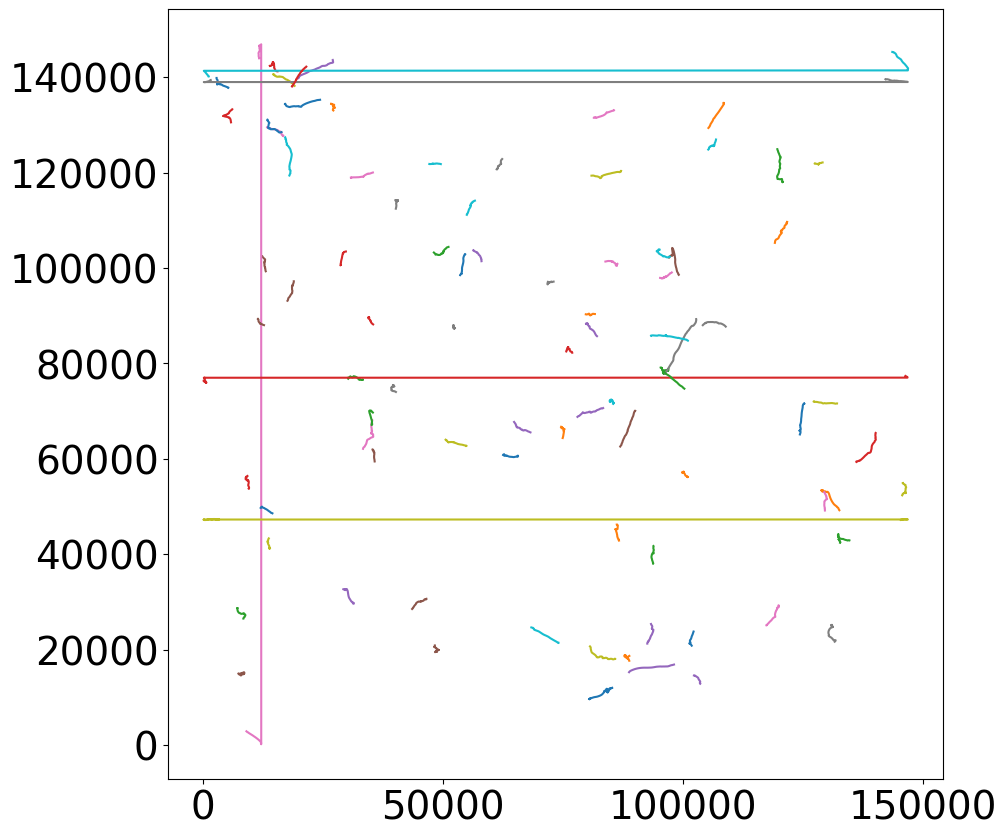

In [60]:
plt.figure(figsize=(10, 10))
for i in range(len(positions['pos_0'][:])):
    plt.plot(positions['pos_0'][:,i], positions['pos_1'][:,i])

In [9]:
for i in totids:
    a = np.all(positions['pos_0'][:,0] == positions['pos_0'][:,i])
    if a:
        print(i, a)


0 True


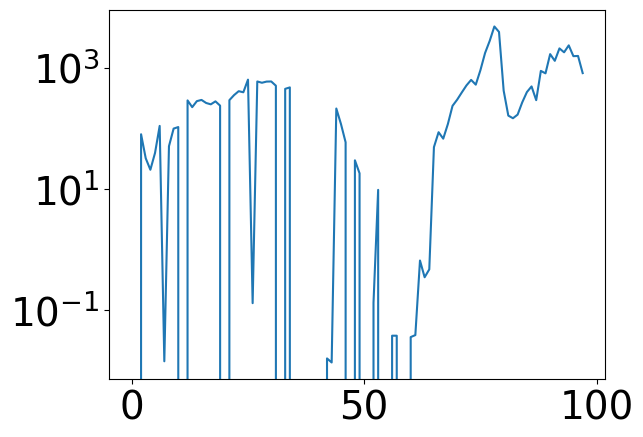

In [45]:
plt.plot(positions['sfr'][:,0])
plt.yscale('log')

In [ ]:
# define our redshift range
z = sb.get_z_from_snap(np.arange(44, 150, 1))
tcosmo = cosmo.age(z).value

indx = -16
print('z = ', z[indx])
print(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), 'Gyr')

In [ ]:
# Specific SFR selection
ssfr = np.log10(positions['sfr'][indx, :] / positions['stellar_masses'][indx, :])
ssfr_cut = ssfr < np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value)
galaxy_selection = np.where(ssfr_cut)[0]
print(f"Number of galaxies selected: {len(galaxy_selection)} over {len(positions['stellar_masses'][indx, :])} total galaxies.")


In [ ]:
import numpy as np

def find_mergers(gal_data, target_ids, indx, z, distance_thresh=0.1, min_consecutive=2):
    """
    Identify potential mergers based on 3D proximity over consecutive snapshots.
    
    Parameters
    ----------
    gal_data : dict
        Dictionary with keys 'pos_x', 'pos_y', 'pos_z', and 'GroupID'.
    target_ids : array-like
        GroupIDs of target galaxies to analyze.
    distance_thresh : float
        Distance threshold in Mpc (default 0.1 = 100 kpc).
    min_consecutive : int
        Minimum number of consecutive snapshots for a close passage.
    
    Returns
    -------
    mergers : dict
        Dictionary mapping each target GroupID to a set of merging GroupIDs.
    """
    pos_x = np.array(gal_data['pos_0'])  # shape (n_snap, n_gal)
    pos_y = np.array(gal_data['pos_1'])
    pos_z = np.array(gal_data['pos_2'])
    group_ids = np.array(gal_data['GroupID']).astype(int)  # shape (n_gal,)
    
    n_snap, n_gal = pos_x.shape
    positions = np.stack([pos_x, pos_y, pos_z], axis=2)  # shape (n_snap, n_gal, 3)
    
    mergers = {}

    # Find indices of target galaxies
    target_mask = np.isin(group_ids[indx, :], target_ids)
    target_indices = np.where(target_mask)[0]
    print(target_indices)
    print(f"Found {len(target_indices)} target galaxies in snapshot {indx}.")
    for tgt_idx in target_indices:
        print(f"Processing target galaxy {group_ids[indx, tgt_idx]} at index {tgt_idx}...")
        tgt_id = group_ids[indx, tgt_idx]
        tgt_pos = positions[:, tgt_idx, :]  # shape (n_snap, 3)

        # Compute 3D distances to all galaxies across snapshots
        dist = np.linalg.norm(positions - tgt_pos[:, np.newaxis, :], axis=2)*0.68  # (n_snap, n_gal)


        # Apply distance threshold (exclude self)
        close_mask = (dist < distance_thresh)
        close_mask[:, tgt_idx] = False  # remove self-match

        # Track galaxies that are within threshold for ≥min_consecutive snapshots
        potential_mergers = set()
        for gal_idx in range(n_gal):
            close_snapshots = close_mask[:, gal_idx]
            # Check for ≥2 consecutive Trues
            if np.any(np.convolve(close_snapshots.astype(int), np.ones(min_consecutive, dtype=int), mode='valid') >= min_consecutive):
                potential_mergers.add(group_ids[indx, gal_idx])
                #print(f"Found potential merger: {group_ids[indx, gal_idx]}")

        mergers[tgt_id] = potential_mergers

    return mergers


In [ ]:
merger_dict = find_mergers(positions, positions['GroupID'][-1, galaxy_selection][:3], 0, z, distance_thresh=100, min_consecutive=4)


In [ ]:
merger_dict.keys()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:30]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    # Plot their positions over time
    plt.figure(figsize=(12, 12))
    for idx in indices:
        plt.plot(pos_x[:, idx], pos_y[:, idx], marker='o', markersize=2, label=f'ID {group_ids[-1, idx]}')
        plt.scatter(pos_x[0, idx], pos_y[0, idx], s=100, label=f'Start Position ID {group_ids[-1, idx]}', edgecolor='black')
    
    plt.xlabel('X [cMpc]')
    plt.ylabel('Y [cMpc]')
    plt.title(f'Galaxy {tgt_id} and Merger Companions (Trajectories)')
    plt.tight_layout()
    plt.show()


In [ ]:
def find_disrupted_galaxies(positions, merger_dict, group_ids):
    pos_x = positions['pos_0']  # shape (n_snap, n_gal)
    n_snap, n_gal = pos_x.shape

    disrupted_info = {}  # key: main galaxy ID, value: list of dicts for disrupted galaxies

    for main_id, candidate_ids in merger_dict.items():
        disrupted_info[main_id] = []
        print(f"Processing main galaxy {main_id} with {len(candidate_ids)} candidates...")

        for cid in candidate_ids:
            # Get index of this candidate galaxy
            try:
                idx = np.where(group_ids == cid)[0][0]
            except IndexError:
                continue  # GroupID not found in last snapshot

            # Track whether the galaxy was alive and when it disappeared
            pos_time_series = pos_x[:, idx]
            not_nan_mask = ~np.isnan(pos_time_series)

            if np.any(not_nan_mask):
                first_nan_after_real = np.where((~not_nan_mask[:-1]) & not_nan_mask[1:])[0]
                # Better logic: find the **first index where it becomes NaN after being real**
                last_real_idx = np.where(not_nan_mask)[0][-1]
                if last_real_idx < n_snap - 1:
                    # Galaxy is gone after last_real_idx
                    snapshot_disrupted = last_real_idx + 1  # first NaN
                    disrupted_info[main_id].append({
                        'id': cid,
                        'disrupted_at': snapshot_disrupted,
                        'index': idx
                    })

    return disrupted_info


In [ ]:
disrupted_info = find_disrupted_galaxies(positions, merger_dict, positions['GroupID'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:3]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    for idx in indices:
        print(pos_x[-1, idx])

    



In [ ]:
positions['pos_0'][:, 10]

In [ ]:
target_mask = np.isin(positions['GroupID'][indx, :], positions['GroupID'][indx, galaxy_selection][:3])
print(target_mask, len(target_mask), positions['GroupID'][indx, :][target_mask])

In [ ]:
plt.plot(positions['GroupID'][indx, :])

In [ ]:

unique_elements, counts = np.unique(positions['GroupID'][-2, :], return_counts=True)

# Now you have:
# - unique_elements: the unique values in the array
# - counts: how many times each unique value appears

# Example: print as dictionary
count_dict = dict(zip(unique_elements, counts))
print(count_dict)

In [48]:
import numpy as np
import h5py
from astropy.io import fits
from astropy.table import Table 

def build_progenitor_groupid_table(simba_obj, snaplist, output_fits, base_snap=151):
    """
    Build a progenitor table: each row corresponds to a galaxy in base_snap,
    and each column gives the GroupID of its main progenitor at that snapshot.
    """
    snaplist = sorted(snaplist, reverse=True)
    print(f'The base snap is {snaplist[0]}')  # descending order
    #if base_snap != snaplist[0]:
    #    raise ValueError("base_snap must be the first snapshot in snaplist")

    print(f"Tracking progenitors from snapshot {base_snap} back to {snaplist[-1]}")
    columns = []
    for si, snap in enumerate(snaplist):
        fpath = simba_obj.get_caesar_file(snap)
        
        with h5py.File(fpath, 'r') as f:
            if si == 0:
                print(f"Processing snapshot {fpath}...")
                print(f"Reading progenitor data from the first snapshot {snap}...")
                prevprog = np.array(f['tree_data']['progen_galaxy_star'][:,0])
                current_indices = np.array(f['galaxy_data']['GroupID'])
                prog_table = np.full((len(current_indices), len(snaplist)), -1, dtype=int)
                valid = np.where(prevprog >= 0)[0]
                prevprog = prevprog[valid]
                print('ID: ,', current_indices)
                print('Progenitor IDs:', prevprog)
                print('=========================================================================')
                
            else:
                print(f"Processing snapshot {fpath}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'])[prevprog][:, 0]
                current_indices = np.array(f['galaxy_data']['GroupID'])
                print('ID: ,', current_indices)
                print('Progenitor IDs:', prevprog)
                valid = np.where(progenid >= 0)[0]
                progenid = progenid[valid]
                
                
            temp = current_indices[prevprog]
            prog_table[prevprog, si] = temp
            print(prog_table[prevprog, si])
            print('=========================================================================')
            if si !=0:
                prevprog = progenid
            


    # Write to FITS file
    for si, snap in enumerate(snaplist):
        columns.append(fits.Column(name=f'{snap}', format='K', array=prog_table[:, si]))
        
               

    hdu = fits.BinTableHDU.from_columns(columns)
    hdu.writeto(output_fits, overwrite=True)
    print(f"Saved progenitor GroupID table to {output_fits}")



    # >>> Print the first 10 rows in a fancy table <<<
    print("\nFirst 10 rows of the saved progenitor table:")
    with fits.open(output_fits) as hdul:
        table = Table(hdul[1].data)
        print(table[:10])


In [53]:
import numpy as np
import h5py
from astropy.io import fits

def build_progenitor_groupid_table(simba_obj, snaplist, output_fits, base_snap=151):
    """
    Build a progenitor table: each row corresponds to a galaxy in base_snap,
    and each column gives the GroupID of its main progenitor at that snapshot.
    """
    snaplist = sorted(snaplist, reverse=True)
    print(f'The base snap is {snaplist[0]}')  # descending order
    #if base_snap != snaplist[0]:
    #    raise ValueError("base_snap must be the first snapshot in snaplist")

    print(f"Tracking progenitors from snapshot {base_snap} back to {snaplist[-1]}")
    columns = []
    for si, snap in enumerate(snaplist):
        fpath = simba_obj.get_caesar_file(snap)

        with h5py.File(fpath, 'r') as f:
            if si == 0:
                print(f"Processing snapshot {fpath}...")
                print(f"Reading progenitor data from the first snapshot {snap}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'][:,0])
                current_indices = np.array(f['galaxy_data']['GroupID'])
                prevprog = current_indices
                prog_table = np.full((len(current_indices), len(snaplist)), -1, dtype=int)
                print('ID: ,', current_indices)
                print('Progenitor IDs:', progenid)
                print('=========================================================================')

            else:
                print(f"Processing snapshot {fpath}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'])[prevprog][:, 0]
                current_indices = np.array(f['galaxy_data']['GroupID'])
                print('ID: ,', current_indices)
                print('Progenitor IDs:', prevprog)
                valid = np.where(progenid >= 0)[0]
                progenid = progenid[valid]


            # prevprog gives you the index in current snapshot of the progenitor of galaxy i at base snapshot
            valid = np.where(prevprog >= 0)[0]  # these are the base snapshot galaxy indices
            prog_table[valid, si] = current_indices[prevprog[valid]]

            print(prog_table[prevprog, si])
            print('=========================================================================')

            prevprog = progenid



    # Write to FITS file
    for si, snap in enumerate(snaplist):
        columns.append(fits.Column(name=f'{snap}', format='K', array=prog_table[:, si]))

    table_hdu = fits.BinTableHDU.from_columns(columns)
    table_hdu.header['EXTNAME'] = 'PROGENITOR_GROUPIDS'

    # Add Primary HDU
    primary_hdu = fits.PrimaryHDU()
    hdul = fits.HDUList([primary_hdu, table_hdu])
    hdul.writeto(output_fits, overwrite=True)

    print(f"Saved progenitor GroupID table to {output_fits}")

In [14]:
import numpy as np
import h5py
from astropy.io import fits
from astropy.table import Table

def build_progenitor_groupid_table(simba_obj, snaplist, output_fits, base_snap=151):
    """
    Build a progenitor table: each row corresponds to a galaxy in base_snap,
    and each column gives the GroupID of its main progenitor at that snapshot.
    """
    snaplist = sorted(snaplist, reverse=True)
    print(f'The base snap is {snaplist[0]}')  # descending order

    print(f"Tracking progenitors from snapshot {base_snap} back to {snaplist[-1]}")
    prog_table = None

    for si, snap in enumerate(snaplist):
        fpath = simba_obj.get_caesar_file(snap)

        with h5py.File(fpath, 'r') as f:
            if si == 0:
                print(f"Processing snapshot {fpath}...")
                print(f"Reading progenitor data from the first snapshot {snap}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'][:, 0])
                current_indices = np.array(f['galaxy_data']['GroupID'])
                prevprog = current_indices
                prog_table = np.full((len(current_indices), len(snaplist)), -1, dtype=int)
                print('GroupIDs: ', current_indices)
                print('Initial progenitor indices:', progenid)
                print('=========================================================================')

            else:
                print(f"Processing snapshot {fpath}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'])[prevprog][:, 0]
                current_indices = np.array(f['galaxy_data']['GroupID'])
                print('Current GroupIDs: ', current_indices)
                print('Progenitor indices from previous step:', prevprog)
                valid = np.where(progenid >= 0)[0]
                progenid = progenid[valid]

            # prevprog are indices into progenitor array
            valid = np.where(prevprog >= 0)[0]
            prog_table[valid, si] = current_indices[prevprog[valid]]

            print(prog_table[valid, si])
            print('=========================================================================')

            prevprog = progenid

    # Build Astropy Table
    colnames = [str(snap) for snap in snaplist]
    table = Table(prog_table, names=colnames)

    # Write to FITS file
    table.write(output_fits, format='fits', overwrite=True)
    print(f"Saved progenitor GroupID table to {output_fits}")

    # Print first 10 rows nicely
    print("\nFirst 10 rows of the progenitor table:\n")
    print(table[:10])


In [18]:
from modules.io_paths import SavePaths
import h5py
cs = sb.get_caesar(151)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sb = anal.Simba('PC39BP4', size=100)
snaplist = list(range(151, 61, -1))  # or whatever range you need
paths = SavePaths()
outdir = paths.create_subdir(paths.get_filetype_path('fits'), 'progenitors_files')
output_fits = os.path.join(outdir, 'progenitors_recursive.fits')

build_progenitor_groupid_table(sb, snaplist, output_fits)


yt : [INFO     ] 2025-06-19 12:47:33,089 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_151.hdf5
yt : [INFO     ] 2025-06-19 12:47:33,098 Found 464043 halos
yt : [INFO     ] 2025-06-19 12:47:33,101 Found 55609 galaxies


The base snap is 151
Tracking progenitors from snapshot 151 back to 62
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_151.hdf5...
Reading progenitor data from the first snapshot 151...
GroupIDs:  [    0     1     2 ... 55606 55607 55608]
Initial progenitor indices: [ 0  1  2 ... -1 -1 -1]
[    0     1     2 ... 55606 55607 55608]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_150.hdf5...
Current GroupIDs:  [    0     1     2 ... 55333 55334 55335]
Progenitor indices from previous step: [ 0  1  2 ... -1 -1 -1]
[    0     1     2 ... 55257 54582 50133]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_149.hdf5...
Current GroupIDs:  [    0     1     2 ... 55058 55059 55060]
Progenitor indices from previous step: [    0     1     2 ... 52407 50861 53237]
[    0     1     2 ... 52407 50861 53237]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_148.hdf5...
Current GroupIDs:  [    0     1     2 ... 54403 54404 544

In [53]:
a = np.array([1, 2, 3, 4, 5])
b = a[[3,2,3,0,1]]
print(b)  # Output: [4 3 4 1 2]

[4 3 4 1 2]


In [74]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

def plot_xy_progenitor_paths(fits_x, fits_y, row_indices=None, label_rows=True):
    # Load FITS files
    with fits.open(fits_x) as hdul_x, fits.open(fits_y) as hdul_y:
        data_x = hdul_x[1].data
        data_y = hdul_y[1].data
        colnames_x = hdul_x[1].columns.names
        colnames_y = hdul_y[1].columns.names

    # Sanity check: same column names
    if set(colnames_x) != set(colnames_y):
        raise ValueError("The x and y FITS files must have the same column names (snapshots).")

    # Sort by snapshot number
    try:
        snaps = np.array([int(c) for c in colnames_x])
    except ValueError:
        raise ValueError("Snapshot column names must be integers (e.g. 151, 150, ...)")

    sort_idx = np.argsort(snaps)
    snaps = snaps[sort_idx]
    sorted_cols = [colnames_x[i] for i in sort_idx]

    # Convert tables to arrays (shape: ngalaxies × nsnapshots)
    x_vals = np.vstack([data_x[col] for col in sorted_cols]).T
    y_vals = np.vstack([data_y[col] for col in sorted_cols]).T

    if row_indices is None:
        row_indices = [0]  # default: first row only

    # Plot
    plt.figure(figsize=(7, 7))
    for i in row_indices:
        plt.plot(x_vals[i], y_vals[i], marker='o', label=f"Galaxy {i}" if label_rows else None)

    plt.xlabel("X [kpc]")
    plt.ylabel("Y [kpc]")
    plt.title("Progenitor X–Y Trajectories")
    if label_rows:
        plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


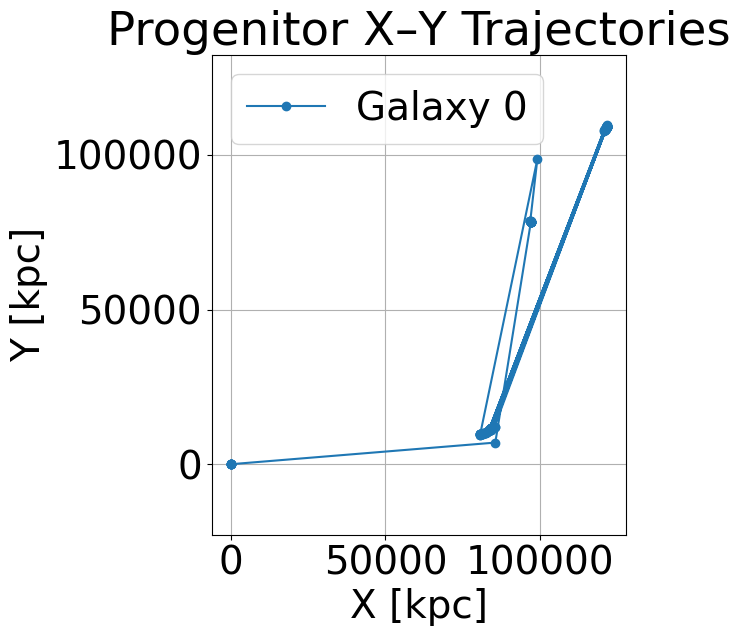

In [75]:
plot_xy_progenitor_paths('/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive_0.fits', '/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive_1.fits')


In [91]:
f = h5py.File('/media/lorenzong/Data1/SIMBA_catalogs/m100n1024_045.hdf5', 'r')
groupids = f['galaxy_data']['GroupID'][:]
np.all(groupids == np.arange(len(groupids)))


True

In [11]:
from modules.anal_func import read_progenitors
read_progenitors.read_descendants_using_groupid([0,1,2,3,4], np.arange(45, 149),
                                                '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', sb,
                                                '/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/miarrendo.fits')

Reading snapshot 148: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_148.fits
Reading snapshot 147: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_147.fits
Reading snapshot 146: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_146.fits
Reading snapshot 145: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_145.fits
Reading snapshot 144: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_144.fits
Reading snapshot 143: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_143.fits
Reading snapshot 142: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_142.fits
Reading snapshot 141: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_141.fits
Reading snapshot 140: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_140.fits
Reading snapshot 139: /home/lorenzong

yt : [INFO     ] 2025-06-19 14:23:11,155 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_092.hdf5
yt : [INFO     ] 2025-06-19 14:23:11,178 Found 544151 halos
yt : [INFO     ] 2025-06-19 14:23:11,182 Found 35805 galaxies
yt : [INFO     ] 2025-06-19 14:23:11,183 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_091.hdf5
yt : [INFO     ] 2025-06-19 14:23:11,193 Found 544762 halos
yt : [INFO     ] 2025-06-19 14:23:11,199 Found 35586 galaxies


selecting 0 0
Analyzing galaxy 0 at snap 30 (GroupID: 0), with position [82973.234375   10417.82617188 56140.70703125] kpccm and velocity [82973.234375   10417.82617188 56140.70703125] kpccm.


yt : [INFO     ] 2025-06-19 14:23:12,829 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_093.hdf5
yt : [INFO     ] 2025-06-19 14:23:12,837 Found 543504 halos
yt : [INFO     ] 2025-06-19 14:23:12,840 Found 36047 galaxies
yt : [INFO     ] 2025-06-19 14:23:12,841 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_092.hdf5
yt : [INFO     ] 2025-06-19 14:23:12,849 Found 544151 halos
yt : [INFO     ] 2025-06-19 14:23:12,852 Found 35805 galaxies


Found 9 neighbors in snap 30 and 9 in snap 31.
Masses of neighbors: stellar=2.43e+12 Msun, dm=0.00e+00 Msun in snap 30, stellar=2.43e+12 Msun, dm=0.00e+00 Msun in snap 31.
selecting 0 0
Analyzing galaxy 0 at snap 31 (GroupID: 0), with position [83169.7109375  10591.31933594 56078.1015625 ] kpccm and velocity [83169.7109375  10591.31933594 56078.1015625 ] kpccm.


yt : [INFO     ] 2025-06-19 14:23:14,534 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_094.hdf5
yt : [INFO     ] 2025-06-19 14:23:14,543 Found 542777 halos
yt : [INFO     ] 2025-06-19 14:23:14,546 Found 36277 galaxies
yt : [INFO     ] 2025-06-19 14:23:14,547 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_093.hdf5
yt : [INFO     ] 2025-06-19 14:23:14,555 Found 543504 halos
yt : [INFO     ] 2025-06-19 14:23:14,558 Found 36047 galaxies


...

yt : [INFO     ] 2025-06-19 14:23:31,708 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_103.hdf5
yt : [INFO     ] 2025-06-19 14:23:31,716 Found 532653 halos
yt : [INFO     ] 2025-06-19 14:23:31,719 Found 38709 galaxies
yt : [INFO     ] 2025-06-19 14:23:31,720 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_102.hdf5
yt : [INFO     ] 2025-06-19 14:23:31,728 Found 533947 halos
yt : [INFO     ] 2025-06-19 14:23:31,731 Found 38550 galaxies


selecting 1 1
Analyzing galaxy 0 at snap 41 (GroupID: 1), with position [83507.21875    11126.45996094 55603.01953125] kpccm and velocity [83507.21875    11126.45996094 55603.01953125] kpccm.
Found 9 neighbors in snap 41 and 7 in snap 42.
Masses of neighbors: stellar=2.24e+12 Msun, dm=0.00e+00 Msun in snap 41, stellar=2.34e+12 Msun, dm=0.00e+00 Msun in snap 42.


yt : [INFO     ] 2025-06-19 14:23:34,042 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_104.hdf5
yt : [INFO     ] 2025-06-19 14:23:34,050 Found 531371 halos
yt : [INFO     ] 2025-06-19 14:23:34,053 Found 38999 galaxies
yt : [INFO     ] 2025-06-19 14:23:34,054 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_103.hdf5
yt : [INFO     ] 2025-06-19 14:23:34,062 Found 532653 halos
yt : [INFO     ] 2025-06-19 14:23:34,065 Found 38709 galaxies


selecting 1 0
Analyzing galaxy 0 at snap 42 (GroupID: 1), with position [83586.5546875  11196.40820312 55506.171875  ] kpccm and velocity [83586.5546875  11196.40820312 55506.171875  ] kpccm.


KeyboardInterrupt: 

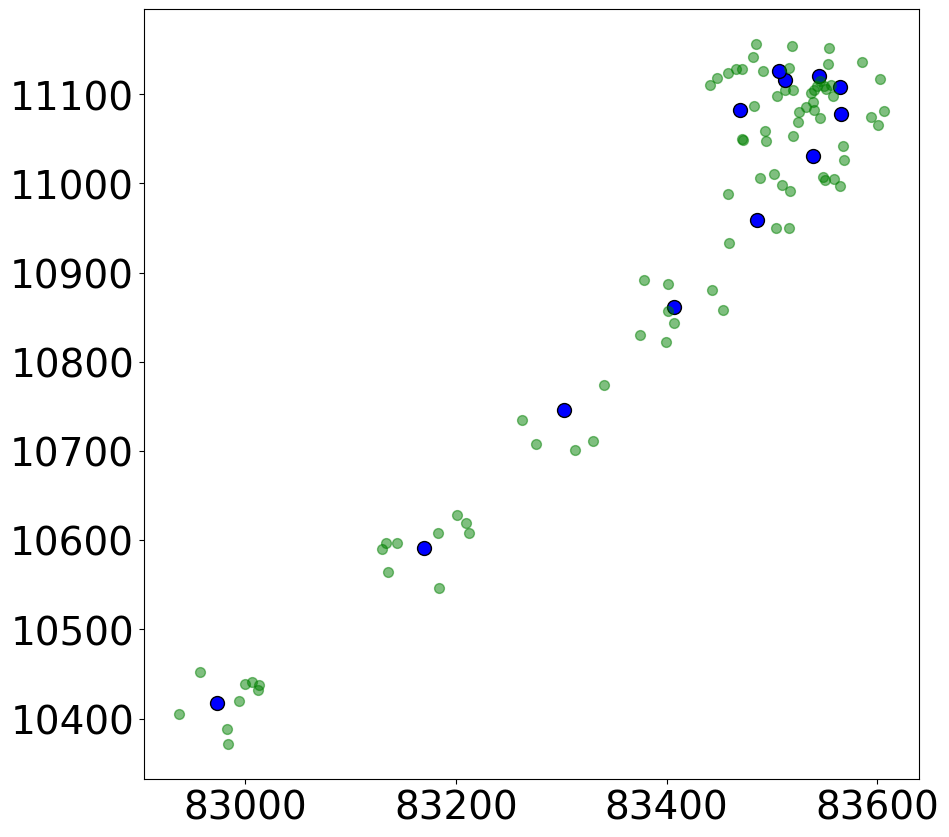

In [3]:
import caesar
import numpy as np
from astropy.io import fits
from pathlib import Path
import gc
import matplotlib.pyplot as plt
gc.collect()


# Parameters
caesar_dir = Path("/media/lorenzong/Data1/SIMBA_catalogs/")
fits_file = "/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive.fits"
search_radius_kpc = 50  # physical kpc
velocity_threshold = 300  # km/s
shared_star_threshold = 0.5  # fraction of lost galaxy's stars found in the main galaxy
major_merger_threshold = 1/4  # 1:3 or greater is major merger

# Load progenitor index table
with fits.open(fits_file) as hdul:
    progenitor_data = hdul[1].data  # record array
    snap_names = hdul[1].columns.names[::-1]  # column names (snapshots)

# Convert to 2D array of shape (n_galaxies, n_snaps)
progenitor_table = np.vstack([progenitor_data[col] for col in snap_names]).T
n_galaxies, n_snaps = progenitor_table.shape

def get_catalog(snapnum):
    fname = caesar_dir / f"m100n1024_{snapnum:03d}.hdf5"
    return caesar.load(fname)

# Main loop
for gal_idx in range(n_galaxies)[:3]:
    plt.figure(figsize=(10, 10))
    for snap in range(n_snaps - 1)[30:80]:
        idx1 = progenitor_table[gal_idx, snap]
        idx2 = progenitor_table[gal_idx, snap + 1]
        print('selecting', idx1, idx2)
        if idx1 < 0 or idx2 < 0:
            continue

        cat1 = get_catalog(int(snap_names[snap]))
        cat2 = get_catalog(int(snap_names[snap]) - 1)

        gal1 = cat1.galaxies[idx1]
        gal2 = cat2.galaxies[idx2]

        pos1 = np.array(gal1.pos)
        vel1 = np.array(gal1.vel)
        print(f"Analyzing galaxy {gal_idx} at snap {snap} (GroupID: {gal1.GroupID}), with position {gal1.pos} and velocity {gal1.pos}.")
        

        mstar1 = gal1.masses['stellar']
        mdm1 = gal1.masses['dm']
        slist1 = set(gal1.slist)

        # --- Find nearby galaxies in snapshot 1 ---
        neighbors1 = []
        for g in cat1.galaxies:
            if g.GroupID == gal1.GroupID:
                continue
            dist = np.linalg.norm(np.array(g.pos) - pos1)
            if dist < search_radius_kpc:
                dv = np.linalg.norm(np.array(g.vel) - vel1)
                if dv < velocity_threshold:
                    neighbors1.append(g)

        # --- Find same neighbors in snapshot 2 ---
        pos2 = np.array(gal2.pos)
        vel2 = np.array(gal2.vel)
        mstar2 = gal2.masses['stellar']
        mdm2 = gal2.masses['dm']
        slist2 = set(gal2.slist)

        neighbors2_ids = set()
        for g in cat2.galaxies:
            dist = np.linalg.norm(np.array(g.pos) - pos2)
            dv = np.linalg.norm(np.array(g.vel) - vel2)
            if dist < search_radius_kpc and dv < velocity_threshold:
                neighbors2_ids.add(g.GroupID)



        # --- Identify lost neighbors ---
        lost_neighbors = []
        for g in neighbors1:
            if g.GroupID not in neighbors2_ids:
                lost_neighbors.append(g)

        print(f"Found {len(neighbors1)} neighbors in snap {snap} and {len(neighbors2_ids)} in snap {snap + 1}.")
        print(f"Masses of neighbors: stellar={mstar1:.2e}, dm={mdm1:.2e} in snap {snap}, "
              f"stellar={mstar2:.2e}, dm={mdm2:.2e} in snap {snap + 1}.")
        
        plt.scatter(pos1[0], pos1[1], s=100, c='blue', label='Galaxy 1', edgecolor='black')
        plt.scatter([g.pos[0] for g in neighbors1], [g.pos[1] for g in neighbors1], 
                    s=50, c='green', label='Neighbors in snap 1', alpha=0.5)
        

                # Done with current catalogs — free memory
        del cat1, cat2
        gc.collect()

        # # --- Check if any lost neighbor merged ---
        # for lost in lost_neighbors:
        #     lost_slist = set(lost.slist)
        #     shared_stars = len(slist2.intersection(lost_slist))
        #     frac_shared = shared_stars / len(lost_slist) if lost_slist else 0

        #     if frac_shared >= shared_star_threshold:
        #         # Merger confirmed
        #         mass_ratio = lost.masses['stellar'] / mstar1
        #         merger_type = "major" if mass_ratio > major_merger_threshold else "minor"

        #         print(
        #             f"Galaxy {gal_idx} experienced a {merger_type} merger between "
        #             f"snap {snap} and {snap + 1} with galaxy {lost.GroupID}.\n"
        #             f" - Mass ratio: {mass_ratio:.2f}\n"
        #             f" - {frac_shared*100:.1f}% of stars transferred."
        #         )


In [3]:
import caesar
import numpy as np
from astropy.io import fits
from pathlib import Path
from multiprocessing import Process
import matplotlib.pyplot as plt
import gc
import os

# Parameters
caesar_dir = Path("/media/lorenzong/Data1/SIMBA_catalogs/")
fits_file = "/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive.fits"
search_radius_kpc = 50  # physical kpc
velocity_threshold = 300  # km/s
shared_star_threshold = 0.5  # fraction of lost galaxy's stars found in the main galaxy
major_merger_threshold = 1/4  # 1:3 or greater is major merger

# Load progenitor index table
with fits.open(fits_file) as hdul:
    progenitor_data = hdul[1].data
    snap_names = hdul[1].columns.names[::-1]

progenitor_table = np.vstack([progenitor_data[col] for col in snap_names]).T
n_galaxies, n_snaps = progenitor_table.shape

# Catalog loader
def get_catalog(snapnum):
    fname = caesar_dir / f"m100n1024_{snapnum:03d}.hdf5"
    return caesar.load(fname)

# Main processing function — runs in subprocess
def process_snap(gal_idx, snap, idx1, idx2):
    try:
        snap1 = int(snap_names[snap])
        snap2 = int(snap_names[snap + 1])

        cat1 = get_catalog(snap1)
        cat2 = get_catalog(snap2)

        gal1 = cat1.galaxies[idx1]
        gal2 = cat2.galaxies[idx2]

        pos1 = np.array(gal1.pos)
        vel1 = np.array(gal1.vel)
        mstar1 = gal1.masses['stellar']
        slist1 = set(gal1.slist)

        neighbors1 = []
        for g in cat1.galaxies:
            if g.GroupID == gal1.GroupID:
                continue
            dist = np.linalg.norm(np.array(g.pos) - pos1)
            if dist < search_radius_kpc:
                dv = np.linalg.norm(np.array(g.vel) - vel1)
                if dv < velocity_threshold:
                    neighbors1.append(g)

        pos2 = np.array(gal2.pos)
        vel2 = np.array(gal2.vel)
        mstar2 = gal2.masses['stellar']
        slist2 = set(gal2.slist)

        neighbors2_ids = set()
        for g in cat2.galaxies:
            dist = np.linalg.norm(np.array(g.pos) - pos2)
            dv = np.linalg.norm(np.array(g.vel) - vel2)
            if dist < search_radius_kpc and dv < velocity_threshold:
                neighbors2_ids.add(g.GroupID)

        lost_neighbors = [g for g in neighbors1 if g.GroupID not in neighbors2_ids]

        for lost in lost_neighbors:
            lost_slist = set(lost.slist)
            shared_stars = len(slist2.intersection(lost_slist))
            frac_shared = shared_stars / len(lost_slist) if lost_slist else 0

            if frac_shared >= shared_star_threshold:
                mass_ratio = lost.masses['stellar'] / mstar1
                merger_type = "major" if mass_ratio > major_merger_threshold else "minor"
                print(
                    f"Galaxy {gal_idx} had a {merger_type} merger between snap {snap1} and {snap2} "
                    f"with galaxy {lost.GroupID}. "
                    f"Mass ratio: {mass_ratio:.2f}, Shared stars: {frac_shared*100:.1f}%"
                )

        # Free memory for current catalogs
        del cat1, cat2, gal1, gal2
        gc.collect()

    except Exception as e:
        print(f"Error in gal {gal_idx}, snap {snap}: {e}")

# ---- Loop through galaxies ----
for gal_idx in range(n_galaxies)[:1]:
    for snap in range(n_snaps - 1)[30:40]:
        idx1 = progenitor_table[gal_idx, snap]
        idx2 = progenitor_table[gal_idx, snap + 1]
        if idx1 < 0 or idx2 < 0:
            continue

        p = Process(target=process_snap, args=(gal_idx, snap, idx1, idx2))
        p.start()
        p.join()  # Wait for subprocess to finish and release memory


yt : [INFO     ] 2025-06-19 14:31:41,394 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_092.hdf5
yt : [INFO     ] 2025-06-19 14:31:41,429 Found 544151 halos
yt : [INFO     ] 2025-06-19 14:31:41,437 Found 35805 galaxies
yt : [INFO     ] 2025-06-19 14:31:41,443 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_093.hdf5
yt : [INFO     ] 2025-06-19 14:31:41,458 Found 543504 halos
yt : [INFO     ] 2025-06-19 14:31:41,466 Found 36047 galaxies
yt : [INFO     ] 2025-06-19 14:31:43,160 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_093.hdf5
yt : [INFO     ] 2025-06-19 14:31:43,192 Found 543504 halos
yt : [INFO     ] 2025-06-19 14:31:43,201 Found 36047 galaxies
yt : [INFO     ] 2025-06-19 14:31:43,206 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_094.hdf5
yt : [INFO     ] 2025-06-19 14:31:43,220 Found 542777 halos
yt : [INFO     ] 2025-06-19 14:31:43,228 Found 36277 galaxies
yt : [INFO     ] 2025-06-19 14:31:44,912 Opening /media/lorenzong/Data1/SIMBA_catalogs/m

Galaxy 0 had a minor merger between snap 101 and 102 with galaxy 27000. Mass ratio: 0.00 dimensionless, Shared stars: 92.1%


In [ ]:
import caesar
import numpy as np
from astropy.io import fits
from pathlib import Path
from multiprocessing import Process
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import gc

# Parameters
caesar_dir = Path("/media/lorenzong/Data1/SIMBA_catalogs/")
fits_file = "/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive.fits"
search_radius_kpc = 100  # physical kpc
velocity_threshold = 100  # km/s
shared_star_threshold = 0.5
major_merger_threshold = 1 / 4
plot_dir = Path("plots_combined")
plot_dir.mkdir(exist_ok=True)

nparts = []

# Load progenitor index table
with fits.open(fits_file) as hdul:
    progenitor_data = hdul[1].data
    snap_names = hdul[1].columns.names[::-1]

progenitor_table = np.vstack([progenitor_data[col] for col in snap_names]).T
n_galaxies, n_snaps = progenitor_table.shape

def get_catalog(snapnum):
    fname = caesar_dir / f"m100n1024_{snapnum:03d}.hdf5"
    return caesar.load(fname)

def match_galaxies(neighbors_snap, neighbors_next, dist_thresh, vel_thresh):
    matched = {}
    unmatched_snap = set(neighbors_snap)
    unmatched_next = set(neighbors_next)

    for g_snap in neighbors_snap:
        pos_snap = np.array(g_snap.pos)
        vel_snap = np.array(g_snap.vel)
        best_match = None
        best_score = np.inf

        for g_next in neighbors_next:
            pos_next = np.array(g_next.pos)
            vel_next = np.array(g_next.vel)

            d = np.linalg.norm(pos_next - pos_snap)
            dv = np.linalg.norm(vel_next - vel_snap)

            if d < dist_thresh and dv < vel_thresh:
                score = d + dv  # simple combined metric
                if score < best_score:
                    best_score = score
                    best_match = g_next

        if best_match is not None:
            matched[g_snap] = best_match
            unmatched_next.discard(best_match)
            unmatched_snap.discard(g_snap)

    return matched, unmatched_snap, unmatched_next

def process_galaxy(gal_idx, snap_range):
    import matplotlib.pyplot as plt
    from matplotlib import cm

    fig, ax = plt.subplots(figsize=(10, 10))
    colors = cm.viridis(np.linspace(0, 1, len(snap_range)))
    vector_scale = 5.0  # Adjust for arrow size

    snap1 = int(snap_names[snap_range[0]])
    snap2 = int(snap_names[snap_range[0] + 1])
    cat1 = get_catalog(snap1)
    cat2 = get_catalog(snap2)

    for i, snap in enumerate(snap_range):
        snap1 = int(snap_names[snap])
        snap2 = int(snap_names[snap + 1])

        idx1 = progenitor_table[gal_idx, snap]
        idx2 = progenitor_table[gal_idx, snap + 1]
        if idx1 < 0 or idx2 < 0:
            if i < len(snap_range) - 1:
                del cat1
                cat1 = cat2
                next_snap = int(snap_names[snap + 2])
                cat2 = get_catalog(next_snap)
            continue

        try:
            gal1 = cat1.galaxies[idx1]
            gal2 = cat2.galaxies[idx2]

            pos1 = np.array(gal1.pos)
            vel1 = np.array(gal1.vel)
            mstar1 = gal1.masses['stellar']
            slist1 = set(gal1.slist)

            # Gather neighbors within radius and velocity threshold in cat1
            neighbors1 = []
            for g in cat1.galaxies:
                if g == gal1:
                    continue
                dist = np.linalg.norm(np.array(g.pos) - pos1)
                dv = np.linalg.norm(np.array(g.vel) - vel1)
                if dist < search_radius_kpc and dv < velocity_threshold:
                    neighbors1.append(g)

            # Gather neighbors within radius and velocity threshold in cat2 (for matching)
            neighbors2 = []
            for g in cat2.galaxies:
                dist = np.linalg.norm(np.array(g.pos) - np.array(gal2.pos))
                dv = np.linalg.norm(np.array(g.vel) - np.array(gal2.vel))
                if dist < search_radius_kpc and dv < velocity_threshold:
                    neighbors2.append(g)

            # Use match_galaxies to find matches and lost neighbors
            matched, unmatched_snap, unmatched_next = match_galaxies(neighbors1, neighbors2,
                                                                     search_radius_kpc,
                                                                     velocity_threshold)

            print(f"\nGalaxy {gal_idx} at snap {snap1}:")
            print(f" - Found {len(neighbors1)} neighbors in snap {snap1}")
            print(f" - Found {len(neighbors2)} neighbors in snap {snap2}")
            print(f" - Matched {len(matched)} neighbors")
            print(f" - Lost neighbors (unmatched in next snap): {len(unmatched_snap)}")
            print(f"---- Galaxy has {len(gal1.slist)+len(gal1.glist)} paricles in snap {snap1} ----")
            nparts.append(len(gal1.slist) + len(gal1.glist))

            # Plot main galaxy
            ax.scatter(pos1[0], pos1[2], s=100, c=[colors[i]], edgecolor='black', label=f'snap {snap1}')
            ax.quiver(pos1[0], pos1[2], vel1[0], vel1[2],
                      angles='xy', scale_units='xy', scale=vector_scale,
                      color=colors[i], width=0.003, edgecolor='black')
            # Plot neighbors + velocity vectors in snap1
            for g in neighbors1:
                gpos = np.array(g.pos)
                gvel = np.array(g.vel)
                marker = '+' if g.central==0 else 'o'
                ax.scatter(gpos[0], gpos[2], s=40, c=[colors[i]], alpha=0.5, marker=marker)
                ax.quiver(gpos[0], gpos[2], gvel[0], gvel[2],
                        angles='xy', scale_units='xy', scale=vector_scale,
                        color=colors[i], alpha=0.4, width=0.002)

            # Highlight lost neighbors (unmatched from snap1 in snap2)
            for lost in unmatched_snap:
                lost_slist = set(lost.slist)
                shared_stars = len(slist1.intersection(lost_slist))
                frac_shared = shared_stars / len(lost_slist) if lost_slist else 0

                if frac_shared >= shared_star_threshold:
                    mass_ratio = lost.masses['stellar'] / mstar1
                    merger_type = "major" if mass_ratio > major_merger_threshold else "minor"
                    print(
                        f"   - {merger_type.title()} merger with galaxy {lost.GroupID} "
                        f"(mass ratio: {mass_ratio:.2f}, shared stars: {frac_shared:.2%})"
                    )
                    marker = '+' if not lost.is_central else 'o'
                    ax.scatter(lost.pos[0], lost.pos[2], marker=marker, s=80, color='red')


        except Exception as e:
            print(f"Error in gal {gal_idx}, snap {snap1}: {e}")

        if i < len(snap_range) - 1:
            del cat1
            gc.collect()
            cat1 = cat2
            next_snap = int(snap_names[snap + 2])
            cat2 = get_catalog(next_snap)

    ax.set_title(f"Galaxy {gal_idx}: Neighbors Across Snapshots")
    ax.set_xlabel("X [kpc]")
    ax.set_ylabel("Y [kpc]")
    #ax.legend()
    ax.grid(True)
    ax.set_aspect("equal")

    fig.tight_layout()
    outpath = plot_dir / f"gal{gal_idx}_vt{velocity_threshold}_sr{search_radius_kpc}.png"
    fig.savefig(outpath)
    print(f"Saved plot for galaxy {gal_idx} to {outpath}")
    plt.close(fig)






# # ---- Loop through galaxies ----
# for gal_idx in range(n_galaxies)[:1]:  # Change this as needed
#     fig, ax = plt.subplots(figsize=(10, 10))
#     snap_range = range(30, 40)  # Change this as needed
#     p = Process(target=process_galaxy, args=(gal_idx, snap_range, fig, ax))
#     p.start()
#     p.join()

#     fig.tight_layout()
#     fig.savefig(plot_dir / f"gal{gal_idx}_combined.png")
#     plt.close(fig)  # Close the figure to free memory

# for gal_idx in range(n_galaxies)[:1]:  # Adjust number of galaxies as needed
#     fig, ax = plt.subplots(figsize=(10, 10))
#     snap_range = range(30, 40)  # Change this as needed
#     fig, ax = process_galaxy(gal_idx, snap_range, fig, ax)

#     fig.tight_layout()
#     fig.savefig(plot_dir / f"gal{gal_idx}_combined.png")
#     print(f"Saved plot for galaxy {gal_idx} to {plot_dir / f'gal{gal_idx}_combined.png'}")
#     plt.close(fig)


for gal_idx in range(n_galaxies)[:1]:  # Adjust the slice to run more galaxies
    snap_range = range(65, 80)  # Adjust snapshot range
    p = Process(target=process_galaxy, args=(gal_idx, snap_range))
    p.start()
    p.join()


yt : [INFO     ] 2025-06-19 16:11:09,143 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_127.hdf5
yt : [INFO     ] 2025-06-19 16:11:09,171 Found 498983 halos
yt : [INFO     ] 2025-06-19 16:11:09,179 Found 45930 galaxies
yt : [INFO     ] 2025-06-19 16:11:09,186 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_128.hdf5
yt : [INFO     ] 2025-06-19 16:11:09,199 Found 497445 halos
yt : [INFO     ] 2025-06-19 16:11:09,208 Found 46224 galaxies



Galaxy 0 at snap 127:
 - Found 32 neighbors in snap 127
 - Found 10 neighbors in snap 128
 - Matched 0 neighbors
 - Lost neighbors (unmatched in next snap): 32
---- Galaxy has 486556 paricles in snap 127 ----


yt : [INFO     ] 2025-06-19 16:11:11,315 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_129.hdf5
yt : [INFO     ] 2025-06-19 16:11:11,329 Found 495012 halos
yt : [INFO     ] 2025-06-19 16:11:11,337 Found 46575 galaxies



Galaxy 0 at snap 128:
 - Found 9 neighbors in snap 128
 - Found 26 neighbors in snap 129
 - Matched 0 neighbors
 - Lost neighbors (unmatched in next snap): 9
---- Galaxy has 513798 paricles in snap 128 ----


yt : [INFO     ] 2025-06-19 16:11:12,980 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_130.hdf5
yt : [INFO     ] 2025-06-19 16:11:12,994 Found 493746 halos
yt : [INFO     ] 2025-06-19 16:11:13,002 Found 46934 galaxies


...


Galaxy 0 at snap 139:
 - Found 23 neighbors in snap 139
 - Found 22 neighbors in snap 140
 - Matched 9 neighbors
 - Lost neighbors (unmatched in next snap): 14
---- Galaxy has 501290 paricles in snap 139 ----


yt : [INFO     ] 2025-06-19 16:11:34,263 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_141.hdf5
yt : [INFO     ] 2025-06-19 16:11:34,276 Found 477082 halos
yt : [INFO     ] 2025-06-19 16:11:34,285 Found 51450 galaxies



Galaxy 0 at snap 140:
 - Found 21 neighbors in snap 140
 - Found 2 neighbors in snap 141
 - Matched 0 neighbors
 - Lost neighbors (unmatched in next snap): 21
---- Galaxy has 523920 paricles in snap 140 ----


yt : [INFO     ] 2025-06-19 16:11:36,578 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_142.hdf5
yt : [INFO     ] 2025-06-19 16:11:36,592 Found 476243 halos
yt : [INFO     ] 2025-06-19 16:11:36,602 Found 51954 galaxies



Galaxy 0 at snap 141:
 - Found 1 neighbors in snap 141
 - Found 26 neighbors in snap 142
 - Matched 0 neighbors
 - Lost neighbors (unmatched in next snap): 1
---- Galaxy has 668060 paricles in snap 141 ----
Saved plot for galaxy 0 to plots_combined/gal0_vt100_sr100.png


In [ ]:
import caesar
import numpy as np
from astropy.io import fits
from pathlib import Path
from multiprocessing import Process, Queue
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import gc

# Parameters
caesar_dir = Path("/media/lorenzong/Data1/SIMBA_catalogs/")
fits_file = "/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive.fits"
search_radius_kpc = 100  # physical kpc
velocity_threshold = 100  # km/s
shared_star_threshold = 0.5
major_merger_threshold = 1 / 4
plot_dir = Path("plots_combined")
plot_dir.mkdir(exist_ok=True)

# Load progenitor index table
with fits.open(fits_file) as hdul:
    progenitor_data = hdul[1].data
    snap_names = hdul[1].columns.names[::-1]

progenitor_table = np.vstack([progenitor_data[col] for col in snap_names]).T
n_galaxies, n_snaps = progenitor_table.shape

def get_catalog(snapnum):
    fname = caesar_dir / f"m100n1024_{snapnum:03d}.hdf5"
    return caesar.load(fname)

def process_galaxy(gal_idx, snap_range, queue):
    import matplotlib.pyplot as plt
    from matplotlib import cm

    fig, ax = plt.subplots(figsize=(10, 10))
    colors = cm.viridis(np.linspace(0, 1, len(snap_range)))
    vector_scale = 5.0  # Adjust for arrow size

    nparts_local = []
    gal_nsat = []

    snap1 = int(snap_names[snap_range[0]])
    snap2 = int(snap_names[snap_range[0] + 1])
    cat1 = get_catalog(snap1)
    cat2 = get_catalog(snap2)

    for i, snap in enumerate(snap_range):
        snap1 = int(snap_names[snap])
        snap2 = int(snap_names[snap + 1])

        idx1 = progenitor_table[gal_idx, snap]
        idx2 = progenitor_table[gal_idx, snap + 1]
        if idx1 < 0 or idx2 < 0:
            if i < len(snap_range) - 1:
                del cat1
                cat1 = cat2
                next_snap = int(snap_names[snap + 2])
                cat2 = get_catalog(next_snap)
            continue

        try:
            gal1 = cat1.galaxies[idx1]
            gal2 = cat2.galaxies[idx2]

            # Number of particles = stellar + gas (or whatever you want)
            npart = len(gal1.slist) + len(gal1.glist)
            nparts_local.append(npart)

            pos1 = np.array(gal1.pos)
            vel1 = np.array(gal1.vel)
            mstar1 = gal1.masses['stellar']
            slist1 = set(gal1.slist)

            neighbors1 = []
            for g in cat1.galaxies:
                if g.GroupID == gal1.GroupID:
                    continue
                dist = np.linalg.norm(np.array(g.pos) - pos1)
                # if dist < search_radius_kpc:
                #     dv = np.linalg.norm(np.array(g.vel) - vel1)
                #     if dv < velocity_threshold:
                neighbors1.append(g)

            gal_nsat.append(len(neighbors1))
        


            pos2 = np.array(gal2.pos)
            vel2 = np.array(gal2.vel)
            slist2 = set(gal2.slist)

            neighbors2_ids = set()
            for g in cat2.galaxies:
                dist = np.linalg.norm(np.array(g.pos) - pos2)
                dv = np.linalg.norm(np.array(g.vel) - vel2)
                if dist < search_radius_kpc and dv < velocity_threshold:
                    neighbors2_ids.add(g.GroupID)

            lost_neighbors = [g for g in neighbors1 if g.GroupID not in neighbors2_ids]

            print(f"\nGalaxy {gal_idx} at snap {snap1}:")
            print(f" - Found {len(neighbors1)} neighbors in snap {snap1}")
            print(f" - Found {len(neighbors2_ids)} neighbors in snap {snap2}")

            # Plot main galaxy
            ax.scatter(pos1[0], pos1[2], s=100, c=[colors[i]], edgecolor='black', label=f'snap {snap1}')
            ax.quiver(pos1[0], pos1[2], vel1[0], vel1[2],
                      angles='xy', scale_units='xy', scale=vector_scale,
                      color=colors[i], width=0.003, edgecolor='black')

            # Plot neighbors + velocity vectors
            for g in neighbors1:
                gpos = np.array(g.pos)
                gvel = np.array(g.vel)
                ax.scatter(gpos[0], gpos[2], s=40, c=[colors[i]], alpha=0.5)
                ax.quiver(gpos[0], gpos[2], gvel[0], gvel[2],
                          angles='xy', scale_units='xy', scale=vector_scale,
                          color=colors[i], alpha=0.4, width=0.002)

            for lost in lost_neighbors:
                lost_slist = set(lost.slist)
                shared_stars = len(slist2.intersection(lost_slist))
                frac_shared = shared_stars / len(lost_slist) if lost_slist else 0

                if frac_shared >= shared_star_threshold:
                    mass_ratio = lost.masses['stellar'] / mstar1
                    merger_type = "major" if mass_ratio > major_merger_threshold else "minor"
                    print(
                        f"   - {merger_type.title()} merger with galaxy {lost.GroupID} "
                        f"(mass ratio: {mass_ratio:.2f}, shared stars: {frac_shared:.2%})"
                    )
                    ax.scatter(lost.pos[0], lost.pos[2], marker='x', s=80, color='red')

        except Exception as e:
            print(f"Error in gal {gal_idx}, snap {snap1}: {e}")

        if i < len(snap_range) - 1:
            del cat1
            gc.collect()
            cat1 = cat2
            next_snap = int(snap_names[snap + 2])
            cat2 = get_catalog(next_snap)

    ax.set_title(f"Galaxy {gal_idx}: Neighbors Across Snapshots")
    ax.set_xlabel("X [kpc]")
    ax.set_ylabel("Y [kpc]")
    # ax.legend()
    ax.grid(True)
    ax.set_aspect("equal")

    fig.tight_layout()
    outpath = plot_dir / f"gal{gal_idx}_vt{velocity_threshold}_sr{search_radius_kpc}.png"
    fig.savefig(outpath)
    print(f"Saved plot for galaxy {gal_idx} to {outpath}")
    plt.close(fig)

    # Send number of particles back to parent process
    queue.put((gal_idx, nparts_local, gal_nsat))

if __name__ == "__main__":
    from multiprocessing import Queue

    q = Queue()

    for gal_idx in range(n_galaxies)[:1]:  # Adjust the slice to run more galaxies
        snap_range = range(65, 80)  # Adjust snapshot range
        p = Process(target=process_galaxy, args=(gal_idx, snap_range, q))
        p.start()
        p.join()

        gal_id, gal_nparts, gal_nsat = q.get()

        # Write nparts per snapshot to a text file
        with open(f"galaxy_{gal_id}_nparts.txt", "w") as f:
            for snap, npart, nsat in zip(snap_range, gal_nparts, gal_nsat):
                snap_num = int(snap_names[snap])
                f.write(f"{snap} {npart} {nsat}\n")

        print(f"Written nparts for galaxy {gal_id} to galaxy_{gal_id}_nparts.txt")


yt : [INFO     ] 2025-06-19 16:40:41,845 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_127.hdf5
yt : [INFO     ] 2025-06-19 16:40:41,876 Found 498983 halos
yt : [INFO     ] 2025-06-19 16:40:41,887 Found 45930 galaxies
yt : [INFO     ] 2025-06-19 16:40:41,893 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_128.hdf5
yt : [INFO     ] 2025-06-19 16:40:41,907 Found 497445 halos
yt : [INFO     ] 2025-06-19 16:40:41,916 Found 46224 galaxies



Galaxy 0 at snap 127:
 - Found 32 neighbors in snap 127
 - Found 10 neighbors in snap 128


yt : [INFO     ] 2025-06-19 16:40:44,497 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_129.hdf5
yt : [INFO     ] 2025-06-19 16:40:44,511 Found 495012 halos
yt : [INFO     ] 2025-06-19 16:40:44,520 Found 46575 galaxies



Galaxy 0 at snap 128:
 - Found 9 neighbors in snap 128
 - Found 26 neighbors in snap 129


yt : [INFO     ] 2025-06-19 16:40:46,199 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_130.hdf5
yt : [INFO     ] 2025-06-19 16:40:46,212 Found 493746 halos
yt : [INFO     ] 2025-06-19 16:40:46,220 Found 46934 galaxies


...


Galaxy 0 at snap 139:
 - Found 23 neighbors in snap 139
 - Found 22 neighbors in snap 140


yt : [INFO     ] 2025-06-19 16:41:07,919 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_141.hdf5
yt : [INFO     ] 2025-06-19 16:41:07,932 Found 477082 halos
yt : [INFO     ] 2025-06-19 16:41:07,941 Found 51450 galaxies



Galaxy 0 at snap 140:
 - Found 21 neighbors in snap 140
 - Found 2 neighbors in snap 141


yt : [INFO     ] 2025-06-19 16:41:10,307 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_142.hdf5
yt : [INFO     ] 2025-06-19 16:41:10,320 Found 476243 halos
yt : [INFO     ] 2025-06-19 16:41:10,329 Found 51954 galaxies



Galaxy 0 at snap 141:
 - Found 1 neighbors in snap 141
 - Found 26 neighbors in snap 142
Saved plot for galaxy 0 to plots_combined/gal0_vt100_sr100.png
Written nparts for galaxy 0 to galaxy_0_nparts.txt


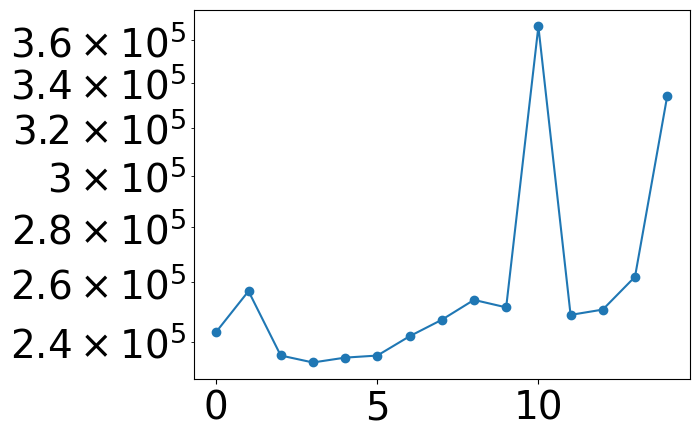

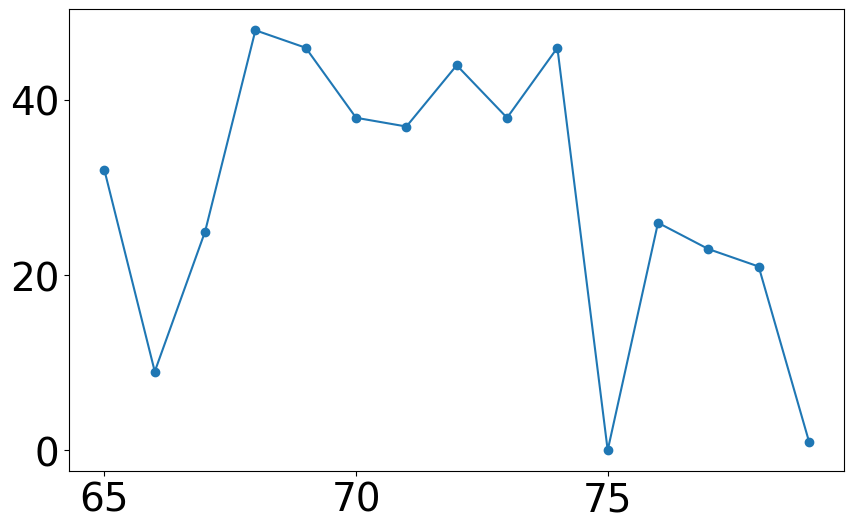

In [46]:
snap, nparts, nsat = np.genfromtxt('galaxy_0_nparts.txt', unpack=True)
plt.plot(nparts, marker='o')
plt.yscale('log')

plt.figure(figsize=(10, 6))
plt.plot(snap, nsat, marker='o', label='Number of Particles')